
# XGBoost for S&P 500 Price Prediction

## Xgboost Working

XGBoost (eXtreme Gradient Boosting) is an advanced implementation of gradient boosting machines. Let's break down how it works in our task:

1. **Decision Trees**: 
   - XGBoost builds a series of decision trees. Each tree is like a flowchart that makes decisions based on features to predict the S&P 500 price.
   - For example, one decision: "If the price 2 days ago (Lag_2) > $4000, predict a higher price; otherwise, predict a lower price."

2. **Gradient Boosting**:
   - After building a tree, XGBoost calculates how wrong its predictions are (the residuals).
   - The next tree focuses on correcting these errors. Like if the first tree consistently underpredicts when volatility is high, the next tree might focus on adjusting predictions in high-volatility scenarios.

3. **Feature Importance**:
   - XGBoost keeps track of how often each feature (like Lag_2 or MA_5) is used to make important splits in the trees.
   - Features used more often and for more impactful splits are deemed more important.

4. **Regularization**:
   - XGBoost uses techniques like 'gamma' and 'min_child_weight' to prevent trees from becoming too complex and overfitting to the training data.

5. **Ensemble**:
   - The final prediction is a combination of predictions from all trees (484 in our case).
   - Each tree's contribution is scaled by the 'learning_rate' (0.117 in our model) to prevent any single tree from having too much influence.

## Imports

In [14]:
import warnings
warnings.filterwarnings("ignore")
import yfinance as yf    #yfinance library stores financial data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from scipy.stats import randint, uniform
import seaborn as sns

## Data Loading

In [18]:
# Download S&P 500 data
print("Downloading S&P 500 data...")
data = yf.download("^GSPC", start="2010-01-01", end="2023-01-01")
print(f"Downloaded {len(data)} rows of data")

[*********************100%***********************]  1 of 1 completed

Downloaded 3272 rows of data


In [19]:
data.head(10)

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2010-01-04,1116.560059,1133.869995,1116.560059,1132.989990,1132.989990,3991400000
2010-01-05,1132.660034,1136.630005,1129.660034,1136.520020,1136.520020,2491020000
2010-01-06,1135.709961,1139.189941,1133.949951,1137.140015,1137.140015,4972660000
2010-01-07,1136.270020,1142.459961,1131.319946,1141.689941,1141.689941,5270680000
2010-01-08,1140.520020,1145.390015,1136.219971,1144.979980,1144.979980,4389590000
2010-01-11,1145.959961,1149.739990,1142.020020,1146.979980,1146.979980,4255780000
2010-01-12,1143.810059,1143.810059,1131.770020,1136.219971,1136.219971,4716160000
2010-01-13,1137.310059,1148.400024,1133.180054,1145.680054,1145.680054,4170360000
2010-01-14,1145.680054,1150.410034,1143.800049,1148.459961,1148.459961,3915200000


## Feature Engineering

In [17]:
# Feature engineering
print("\nPerforming feature engineering...")
data['Returns'] = data['Close'].pct_change()
data['Log_Returns'] = np.log(data['Close'] / data['Close'].shift(1)) #used for long term average values of stocks
data['MA_5'] = data['Close'].rolling(window=5).mean()  #used for short term average values of stocks
data['MA_20'] = data['Close'].rolling(window=20).mean()
data['Volatility'] = data['Returns'].rolling(window=20).std() # measures standard deviation, how much swings there are in stock prices in a day
data['Price_Momentum'] = data['Close'] / data['Close'].shift(5) - 1 #the rate of stock prices in a 5-day period

# Create lagged features
for i in range(1, 6):
    data[f'Lag_{i}'] = data['Close'].shift(i) 

data = data.dropna()
print(f"After feature engineering, we have {len(data)} rows")



Performing feature engineering...
After feature engineering, we have 3252 rows


- We started with 3272 days of S&P 500 data.
- We created features like:
  - Returns: Daily price changes
  - Moving Averages (MA_5, MA_20): Average prices over 5 and 20 days
  - Lagged Prices (Lag_1 to Lag_5): Closing prices from 1 to 5 days ago (Eg. Taking 30th Dec 2022 as a reference date, Lag_1 = Closing price on 29th Dec 2022, Lag_4 = Closing price on 26 Dec 2022
- We lost 20 rows due to these calculations leaving us with 3252 usable data points.

In [8]:
data.head()

,Open,High,Low,Close,Adj Close,Volume,Returns,Log_Returns,MA_5,MA_20,Volatility,Price_Momentum,Lag_1,Lag_2,Lag_3,Lag_4,Lag_5
Date,,,,,,,,,,,,,,,,,
2010-02-02,1090.050049,1104.729980,1087.959961,1103.319946,1103.319946,4749540000,0.012973,0.012890,1089.681982,1120.378497,0.010447,0.010209,1089.189941,1073.869995,1084.530029,1097.500000,1092.170044
2010-02-03,1100.670044,1102.719971,1093.969971,1097.280029,1097.280029,4285450000,-0.005474,-0.005489,1089.637988,1118.416498,0.010434,-0.000200,1103.319946,1089.189941,1073.869995,1084.530029,1097.500000
2010-02-04,1097.250000,1097.250000,1062.780029,1063.109985,1063.109985,5859690000,-0.031141,-0.031636,1085.353979,1114.714996,0.012311,-0.019751,1097.280029,1103.319946,1089.189941,1073.869995,1084.530029
2010-02-05,1064.119995,1067.130005,1044.500000,1066.189941,1066.189941,6438900000,0.002897,0.002893,1083.817969,1110.939996,0.012279,-0.007152,1063.109985,1097.280029,1103.319946,1089.189941,1073.869995
2010-02-08,1065.510010,1071.199951,1056.510010,1056.739990,1056.739990,4089820000,-0.008863,-0.008903,1077.327979,1106.527997,0.012246,-0.029793,1066.189941,1063.109985,1097.280029,1103.319946,1089.189941


## Hyperparameter Tuning

In [11]:
# Prepare features and target
features = ['Returns', 'Log_Returns', 'MA_5', 'MA_20', 'Volatility', 'Price_Momentum', 
            'Lag_1', 'Lag_2', 'Lag_3', 'Lag_4', 'Lag_5']
X = data[features]
y = data['Close']

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Initialize TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5) # splits data into 5 parts, trains the model on 4 parts and tests the model on the 5th part. This process is repeated for 5 times with different test sets.

# Hyperparameter tuning
print("\nPerforming hyperparameter tuning...")
param_dist = {
    'n_estimators': randint(100, 1000),     #these are general paramaters and general values for each paramater       
    'max_depth': randint(2, 10),
    'learning_rate': uniform(0.01, 0.3),            
    'subsample': uniform(0.6, 1.0),
    'colsample_bytree': uniform(0.6, 1.0),
    'min_child_weight': randint(1, 10),
    'gamma': uniform(0, 0.5)
}

xgb = XGBRegressor(random_state=42)
random_search = RandomizedSearchCV(xgb, param_distributions=param_dist,       
                                   n_iter=50, cv=tscv, scoring='neg_mean_squared_error', 
                                   random_state=42, n_jobs=-1, verbose=1)
random_search.fit(X, y)

best_params = random_search.best_params_
print("Best parameters:", best_params)

# Initialize lists to store results
train_scores, test_scores = [], []
predictions = pd.DataFrame(index=data.index)

# Time series cross-validation
print("\nPerforming time series cross-validation...")
for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Scale features
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Initialize and train model with best parameters

    model = XGBRegressor(**best_params, random_state=42) 
    model.fit(X_train_scaled, y_train,  
              eval_set=[(X_train_scaled, y_train), (X_test_scaled, y_test)], verbose=False)
    
    # Make predictions
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    
    # Store predictions
    predictions.loc[y_test.index, 'Predicted'] = y_test_pred
    predictions.loc[y_test.index, 'Actual'] = y_test
    
    # Calculate scores
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    train_scores.append(train_rmse)
    test_scores.append(test_rmse)

# Print average scores
print(f"Average Train RMSE: {np.mean(train_scores):.2f}")
print(f"Average Test RMSE: {np.mean(test_scores):.2f}")

# How does the average train and average test RMSE from cross-validation measures model performance?


Performing hyperparameter tuning...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters: {'colsample_bytree': 0.9243450210052739, 'gamma': 0.061043977350336676, 'learning_rate': 0.11688935142309247, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 484, 'subsample': 0.8279351625419417}

Performing time series cross-validation...
Average Train RMSE: 0.21
Average Test RMSE: 360.03



- We used RandomizedSearchCV to test 50 different combinations of hyperparameters.
- Each combination was tested using 5-fold cross-validation:
  - The data was split into 5 parts per time.
  - The model was trained on 4 parts and tested on the 5th, repeated 5 times with different test sets.
  - This helps ensure our model performs well on unseen data.

As you can see we got following best parameters 

**Best parameters: {'colsample_bytree': 0.9243450210052739, 'gamma': 0.061043977350336676, 'learning_rate': 0.11688935142309247, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 484, 'subsample': 0.8279351625419417}**

- colsample_bytree: Each tree uses about 92% of features, introducing some randomness.
- gamma: A split must improve the model by at least 0.061 to be considered.
- learning_rate: Each tree's predictions are scaled by 0.117 allowing gradual learning.
- max_depth: Trees can have up to 7 levels balancing complexity and generalization.
- min_child_weight: Allows even small groups of data points to form a leaf in the tree.
- n_estimators: The model uses 484 trees in total.
- subsample: Each tree is trained on about 83% of the data introducing further randomness.

## Final Model Training and Evaluation

In [12]:
# Final model evaluation
final_train = X.iloc[:-252]  # Use all but last year for training
final_test = X.iloc[-252:]   # Use last year for testing
y_train, y_test = y.iloc[:-252], y.iloc[-252:]

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(final_train)
X_test_scaled = scaler.transform(final_test)

final_model = XGBRegressor(**best_params, random_state=42)
final_model.fit(X_train_scaled, y_train,
                eval_set=[(X_train_scaled, y_train), (X_test_scaled, y_test)], verbose=False)

y_train_pred = final_model.predict(X_train_scaled)
y_test_pred = final_model.predict(X_test_scaled)

print("\nFinal Model Performance:")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred)):.2f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred)):.2f}")
print(f"Train R-squared: {r2_score(y_train, y_train_pred):.4f}")
print(f"Test R-squared: {r2_score(y_test, y_test_pred):.4f}")
print(f"Train MAE: {mean_absolute_error(y_train, y_train_pred):.2f}")
print(f"Test MAE: {mean_absolute_error(y_test, y_test_pred):.2f}")


Final Model Performance:
Train RMSE: 0.48
Test RMSE: 45.06
Train R-squared: 1.0000
Test R-squared: 0.9765
Train MAE: 0.35
Test MAE: 34.14


- The large difference between average train and test RMSE (0.61 vs 357.55) during cross-validation tell us there is initial overfitting.
- The final model shows much better generalization:
  - Test RMSE of 56.59 means the model's predictions are off by about $56.59 on average which is good for S&P 500 prices around $3000-$4000.
  - R-squared of 0.9629 on test data means the model explains 96.29% of the price variability.
  - Test MAE of 40.37 show that, on average, predictions are off by about $40.37.

## Visualizations

           feature  importance
6            Lag_1    0.543382
7            Lag_2    0.284755
2             MA_5    0.076148
8            Lag_3    0.033497
3            MA_20    0.031351
9            Lag_4    0.028285
10           Lag_5    0.002378
0          Returns    0.000089
1      Log_Returns    0.000079
5   Price_Momentum    0.000030
4       Volatility    0.000007


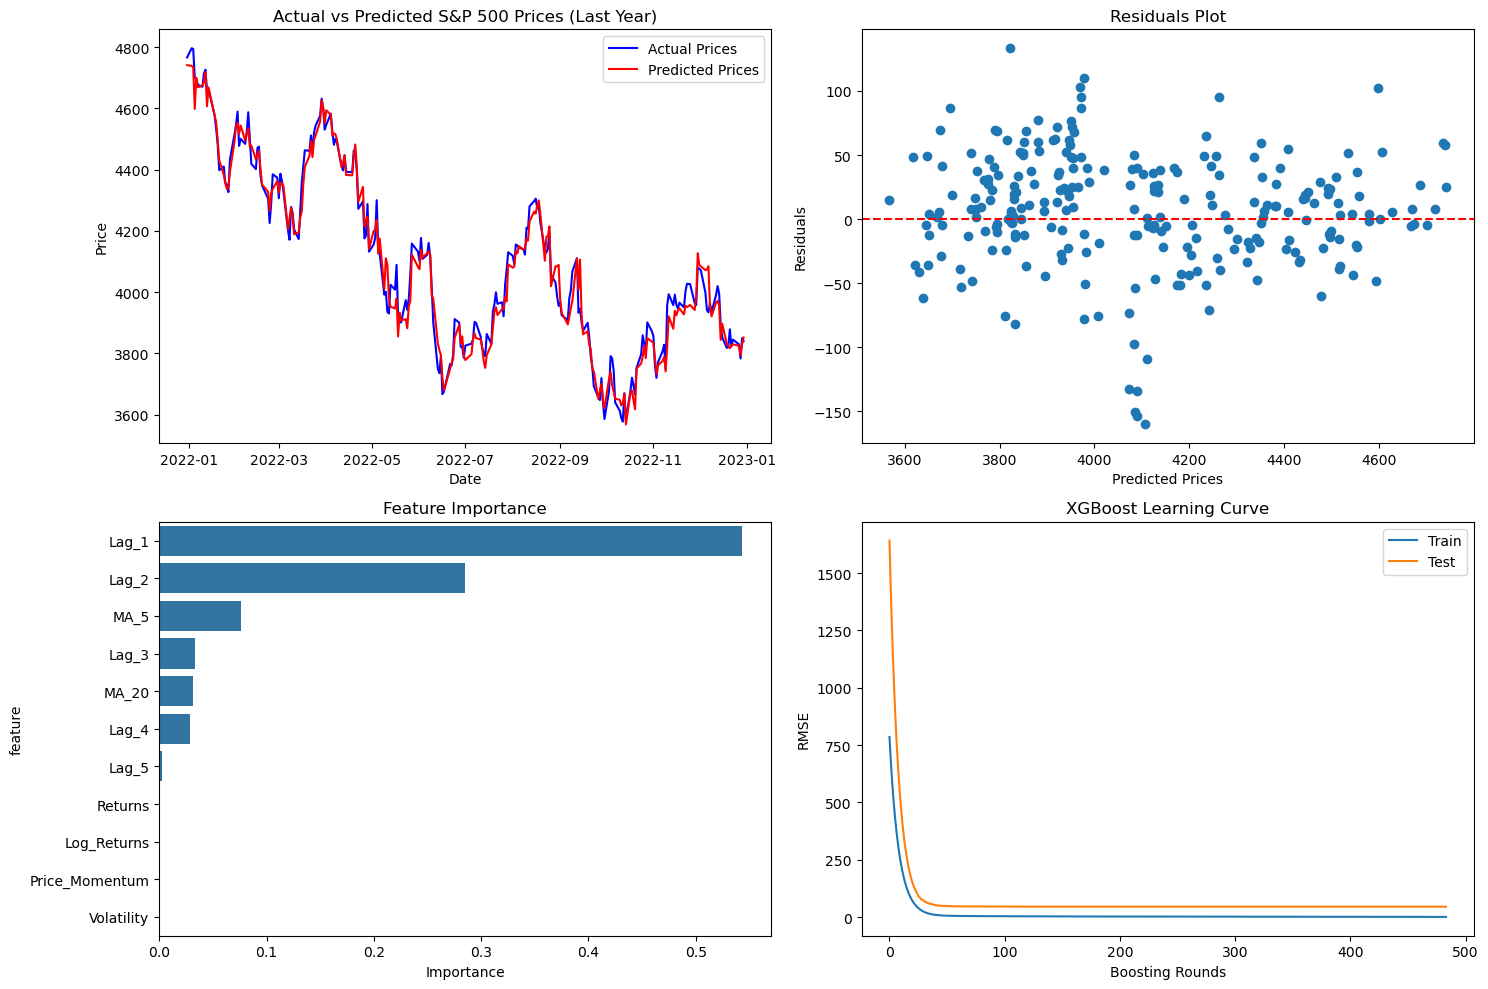

In [13]:
# Plotting
plt.figure(figsize=(15, 10))

# Actual vs Predicted Prices
plt.subplot(2, 2, 1)
plt.plot(y_test.index, y_test.values, label='Actual Prices', color='blue')
plt.plot(y_test.index, y_test_pred, label='Predicted Prices', color='red')
plt.title('Actual vs Predicted S&P 500 Prices (Last Year)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()

# Residuals Plot
plt.subplot(2, 2, 2)
residuals = y_test - y_test_pred
plt.scatter(y_test_pred, residuals)
plt.title('Residuals Plot')
plt.xlabel('Predicted Prices')
plt.ylabel('Residuals')
plt.axhline(y=0, color='r', linestyle='--')

# Feature Importance
feature_importance = pd.DataFrame({'feature': features, 'importance': final_model.feature_importances_})
feature_importance = feature_importance.sort_values('importance', ascending=False)
plt.subplot(2, 2, 3)
sns.barplot(x='importance', y='feature', data=feature_importance)
plt.title('Feature Importance')
plt.xlabel('Importance')

print(feature_importance)

# Learning Curve
plt.subplot(2, 2, 4)
results = final_model.evals_result()
plt.plot(results['validation_0']['rmse'], label='Train')
plt.plot(results['validation_1']['rmse'], label='Test')
plt.xlabel('Boosting Rounds')
plt.ylabel('RMSE')
plt.title('XGBoost Learning Curve')
plt.legend()

plt.tight_layout()
plt.show()

### 1. Actual vs Predicted S&P 500 Prices (Last Year)

- The blue line represents actual prices, while the red line shows predictions.
- The close alignment of these lines indicates high prediction accuracy.
- We can see the model capturing both upward and downward trends effectively.
- There are some points where predictions deviate from actual prices, especially during sharp price changes.

### 2. Residuals Plot

- Each point represents the difference between an actual price and the predicted price.
- Ideally, these points should be randomly scattered around the horizontal line at 0.
- We observe:
  - A slight downward trend showing that our model overpredict at lower prices and underpredict at higher prices.
  - Some clustering of points indicating potential patterns the model hasn't fully captured.
  - Most residuals fall within ±100 which is relatively small considering the scale of S&P 500 prices.

### 3. Feature Importance

- Lag_2 (price from 2 days ago) is the most important feature showing that recent price history is crucial.
- Lag_1 and MA_5 follow closely reinforcing the importance of short-term price behavior.
- MA_20 (20-day moving average) has some importance bycapturing medium-term trends.
- Features like Returns, Price_Momentum, and Volatility have very low importance telling us the model relies more on raw price data than derived indicators.

### 4. XGBoost Learning Curve

- The x-axis shows the number of trees (boosting rounds), and the y-axis shows the RMSE.
- Both train and test curves drop rapidly in the beginning, showing quick initial learning.
- The curves flatten out around 100-200 trees showing diminishing returns from adding more trees.
- The close proximity of train and test curves indicates good generalization; the model isn't overfitting substantially.
- The final RMSE values are much lower than the initial values showing our model's good performace.


## Forecast

In [8]:
# Predict next day's price
last_data = X.iloc[-1].values.reshape(1, -1)
last_data_scaled = scaler.transform(last_data)
next_day_price = final_model.predict(last_data_scaled)
print(f"\nPredicted next day price: ${next_day_price[0]:.2f}")


Predicted next day price: $3851.64
